c:\Users\quzho2904\AppData\Local\anaconda3\envs\GEOF337\lib\site-packages\seabird\cnv.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources



Station times:
2015: 2015-09-21 06:30
2016: 2016-09-20 18:42

===== Deep offset correction =====
Reference layer: deepest common 1 m
Bottom mean sigma0 (2015) = 27.299414
Bottom mean sigma0 (2016) = 27.294112
Offset applied to 2016 = 0.005302

Around 400 m (380–420 m):
Depth (m)     sigma0_2015     sigma0_2016_raw  sigma0_2016_aln  diff16-15
  380.00      27.298121      27.293381      27.298683     0.000563
  381.00      27.298137      27.293397      27.298700     0.000563
  382.00      27.298153      27.293413      27.298716     0.000563
  383.00      27.298169      27.293429      27.298732     0.000563
  384.00      27.298034      27.293446      27.298748     0.000714
  385.00      27.298050      27.293462      27.298764     0.000714
  386.00      27.298066      27.293327      27.298629     0.000563
  387.00      27.298082      27.293343      27.298645     0.000563
  388.00      27.298098      27.293359      27.298661     0.000563
  389.00      27.298265      27.293375      27.29867

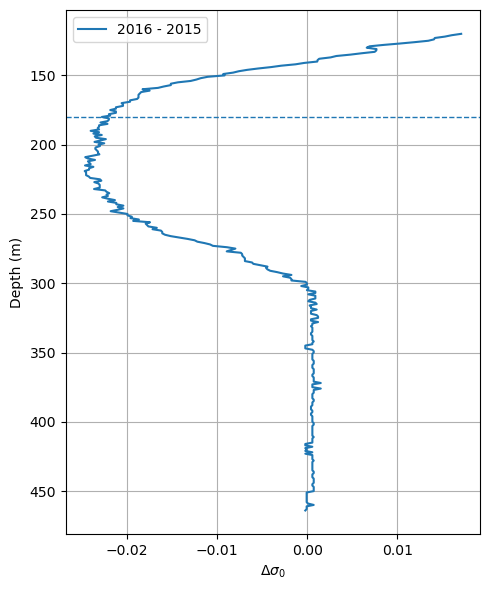

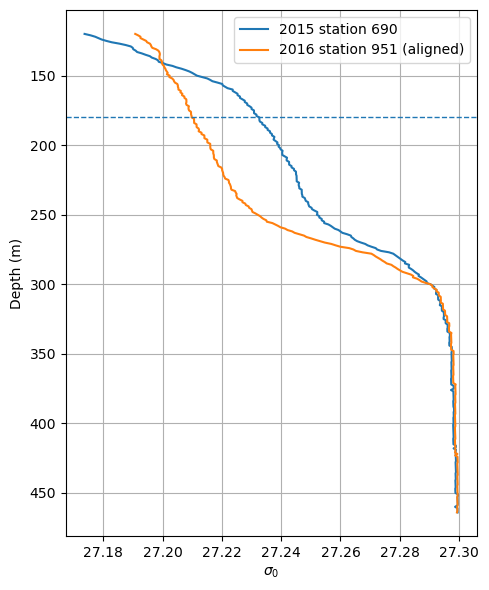

In [1]:
import GFPy.Ocean as Oc
import numpy as np
import gsw
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# Read data
# =========================
file_2015 = r'C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\npy\HM2015620.npy'
file_2016 = r'C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\npy\HM2016619.npy'

CTD_2015 = Oc.read_CTD(file_2015)
CTD_2016 = Oc.read_CTD(file_2016)

# =========================
# Unify LAT/LON field names
# =========================
for CTD in [CTD_2015, CTD_2016]:
    for st in CTD.keys():
        if 'lat' in CTD[st]:
            CTD[st]['LAT'] = CTD[st]['lat']
        if 'lon' in CTD[st]:
            CTD[st]['LON'] = CTD[st]['lon']

# =========================
# Compute TEOS-10 sigma0
# =========================
def compute_sigma0(CTD):
    for st in CTD.keys():
        S = np.asarray(CTD[st]['S'], dtype=float)
        T = np.asarray(CTD[st]['T'], dtype=float)
        z = np.asarray(CTD[st]['P'], dtype=float)

        lon = float(CTD[st]['LON'])
        lat = float(CTD[st]['LAT'])

        p = z.copy()

        n = min(len(S), len(T), len(p))
        S = S[:n]
        T = T[:n]
        p = p[:n]

        valid = np.isfinite(S) & np.isfinite(T) & np.isfinite(p)
        S = S[valid]
        T = T[valid]
        p = p[valid]

        SA = gsw.SA_from_SP(S, p, lon, lat)
        CT = gsw.CT_from_t(SA, T, p)

        CTD[st]['P'] = p
        CTD[st]['S'] = S
        CTD[st]['T'] = T
        CTD[st]['SIGTH'] = gsw.sigma0(SA, CT)

compute_sigma0(CTD_2015)
compute_sigma0(CTD_2016)

# =========================
# Helper: get station safely
# =========================
def get_station_data(CTD, station_id):
    if station_id in CTD:
        return CTD[station_id]
    if str(station_id) in CTD:
        return CTD[str(station_id)]
    raise KeyError(f"Station {station_id} not found. Available keys example: {list(CTD.keys())[:10]}")

# =========================
# Helper: get station datetime safely
# =========================
def get_station_time(st):
    for key in ["datetime", "time", "TIME"]:
        if key in st:
            return str(st[key])
    return "unknown"

# =========================
# Select stations
# =========================
station_2015_id = 690
station_2016_id = 951

st2015 = get_station_data(CTD_2015, station_2015_id)
st2016 = get_station_data(CTD_2016, station_2016_id)

time_2015 = get_station_time(st2015)
time_2016 = get_station_time(st2016)

print("\nStation times:")
print("2015:", time_2015)
print("2016:", time_2016)

z1 = np.asarray(st2015['P'], dtype=float)
z2 = np.asarray(st2016['P'], dtype=float)

sig1 = np.asarray(st2015['SIGTH'], dtype=float)
sig2 = np.asarray(st2016['SIGTH'], dtype=float)

# =========================
# Match true common depth levels
# =========================
# Since your profiles are essentially on 1 dbar levels,
# round to 3 decimals to avoid tiny float mismatches.
z1_round = np.round(z1, 3)
z2_round = np.round(z2, 3)

common_depths = np.intersect1d(z1_round, z2_round)

if len(common_depths) < 5:
    raise ValueError("Too few common depth levels found between the two profiles.")

# build lookup tables
sig1_map = {zz: vv for zz, vv in zip(z1_round, sig1)}
sig2_map = {zz: vv for zz, vv in zip(z2_round, sig2)}

z_common = common_depths
sig1_common = np.array([sig1_map[zz] for zz in z_common], dtype=float)
sig2_common = np.array([sig2_map[zz] for zz in z_common], dtype=float)

# Raw difference
dsig_2016_minus_2015_raw = sig2_common - sig1_common

# =========================
# Deep alignment using deepest common 1 m
# =========================
bottom_window_m = 10.0
zmax_common = np.nanmax(z_common)

mask_bottom = z_common >= (zmax_common - bottom_window_m)

if np.sum(mask_bottom) < 1:
    raise ValueError("No points found in the deepest common 10 m layer for offset correction.")

bottom_mean_2015 = np.nanmean(sig1_common[mask_bottom])
bottom_mean_2016 = np.nanmean(sig2_common[mask_bottom])

# Take 2015 as reference
offset_2016 = bottom_mean_2016 - bottom_mean_2015

sig1_aligned = sig1_common.copy()
sig2_aligned = sig2_common - offset_2016

# Recompute difference after alignment
dsig_2016_minus_2015 = sig2_aligned - sig1_aligned

print("\n===== Deep offset correction =====")
print("Reference layer: deepest common 1 m")
print(f"Bottom mean sigma0 (2015) = {bottom_mean_2015:.6f}")
print(f"Bottom mean sigma0 (2016) = {bottom_mean_2016:.6f}")
print(f"Offset applied to 2016 = {-offset_2016:.6f}")

# =========================
# Print selected depth range
# =========================
mask = (z_common >= 380) & (z_common <= 420)

print('\nAround 400 m (380–420 m):')
print('Depth (m)     sigma0_2015     sigma0_2016_raw  sigma0_2016_aln  diff16-15')

for i in np.where(mask)[0]:
    print(
        f'{z_common[i]:8.2f}   '
        f'{sig1_aligned[i]:12.6f}   '
        f'{sig2_common[i]:12.6f}   '
        f'{sig2_aligned[i]:12.6f}   '
        f'{dsig_2016_minus_2015[i]:10.6f}'
    )

if np.any(mask):
    print('\nStatistics in this depth range after alignment:')
    print('mean diff (2016-2015) =', np.nanmean(dsig_2016_minus_2015[mask]))
    print('max diff  (2016-2015) =', np.nanmax(dsig_2016_minus_2015[mask]))
    print('min diff  (2016-2015) =', np.nanmin(dsig_2016_minus_2015[mask]))
else:
    print('\nNo common data points in 380–420 m.')

# =========================
# Save sigma0 data
# =========================
save_csv = r'C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\sigma0_station690_2015_vs_station951_2016_aligned.csv'
save_npy = r'C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\sigma0_station690_2015_vs_station951_2016_aligned.npy'

df_save = pd.DataFrame({
    'depth_m': z_common,
    'sigma0_2015_raw': sig1_common,
    'sigma0_2016_raw': sig2_common,
    'sigma0_2015_aligned': sig1_aligned,
    'sigma0_2016_aligned': sig2_aligned,
    'sigma0_diff_2016_minus_2015_raw': dsig_2016_minus_2015_raw,
    'sigma0_diff_2016_minus_2015': dsig_2016_minus_2015,
    'datetime_2015': time_2015,
    'datetime_2016': time_2016
})

df_save.to_csv(save_csv, index=False, encoding='utf-8-sig')

save_dict = {
    'depth_m': z_common,
    'sigma0_2015_raw': sig1_common,
    'sigma0_2016_raw': sig2_common,
    'sigma0_2015_aligned': sig1_aligned,
    'sigma0_2016_aligned': sig2_aligned,
    'sigma0_diff_2016_minus_2015_raw': dsig_2016_minus_2015_raw,
    'sigma0_diff_2016_minus_2015': dsig_2016_minus_2015,
    'bottom_mean_2015': bottom_mean_2015,
    'bottom_mean_2016': bottom_mean_2016,
    'offset_2016_relative_to_2015': offset_2016,
    'station_2015_id': station_2015_id,
    'station_2016_id': station_2016_id,
    'datetime': {
        '2015': time_2015,
        '2016': time_2016
    }
}

np.save(save_npy, save_dict)

print(f'\nSaved csv to:\n{save_csv}')
print(f'Saved npy to:\n{save_npy}')

# =========================
# Plot sigma0 difference profile
# =========================
mask_deep = z_common >= 120

plt.figure(figsize=(5, 6))
plt.plot(dsig_2016_minus_2015[mask_deep], z_common[mask_deep], label='2016 - 2015')
plt.axhline(180, linestyle='--', linewidth=1)
plt.gca().invert_yaxis()
plt.xlabel(r'$\Delta \sigma_0$')
plt.ylabel('Depth (m)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# =========================
# Plot aligned sigma0 profiles
# =========================
plt.figure(figsize=(5, 6))
plt.plot(sig1_aligned[mask_deep], z_common[mask_deep], label=f'2015 station {station_2015_id}')
plt.plot(sig2_aligned[mask_deep], z_common[mask_deep], label=f'2016 station {station_2016_id} (aligned)')
plt.axhline(180, linestyle='--', linewidth=1)
plt.gca().invert_yaxis()
plt.xlabel(r'$\sigma_0$')
plt.ylabel('Depth (m)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()